In [1]:
import os 
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from glob import glob
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

import warnings 
warnings.filterwarnings('ignore') 

import seaborn as sns
from anndata import AnnData
from scipy.stats import pearsonr, spearmanr, wilcoxon

sys.path.append("./STAN")
import stan

In [2]:
sample_list = os.listdir("./../data/st_data/")
print(sample_list)

['GSM6506115_SP6', 'GSM6506111_SP2', 'GSM6506110_SP1', 'GSM6506113_SP4', 'GSM6506116_SP7', 'GSM6506114_SP5', 'GSM6506112_SP3', 'GSM6506117_SP8']


## Loading ST datasets

In [3]:
adatas = dict()
for sample in sample_list:
    adatas[sample] = sc.read_h5ad("./../data/st_qc/{}.h5ad".format(sample))
adatas

{'GSM6506115_SP6': AnnData object with n_obs × n_vars = 1792 × 18341
     obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'chemo_response', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
     uns: 'spatial'
     obsm: 'spatial',
 'GSM6506111_SP2': AnnData object with n_obs × n_vars = 1932 × 17815
     obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'chemo_response', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
     uns: 'spatial'
     obsm: 'spatial',
 'GSM6506110_SP1': AnnData object with n_obs × n_vars = 2930 × 19003
     obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'chemo_response', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
     uns: 'spatial'
     obsm: 'spatial',
 'GSM6506113_SP4': AnnData object with n_obs × n_vars = 3002 × 18208
     obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'chemo_response', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
     uns: 

## Loading the gene-pathway prior matrix

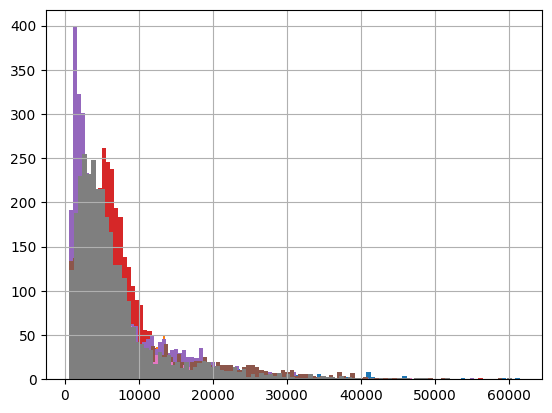

In [4]:
for sample in sample_list:
    adatas[sample].layers['raw'] = adatas[sample].X
    adatas[sample].obs['ncounts'] = adatas[sample].to_df('raw').T.sum()
    adatas[sample].obs['ncounts'].hist(bins=100)

In [5]:
from typing import Optional, Union, Literal, List

def add_gene_pathway_matrix(
        data: AnnData,
        min_cells_proportion: float = 0.2,
        min_genes_per_pathway: int = 3,
        source_dir: str = "./STAN/resources/"
        ) -> Union[AnnData, None]:

    adata = data.copy()
    sc.pp.filter_genes(adata, min_cells=min_cells_proportion*adata.n_obs)
    gene_universe=adata.var_names

    if source_dir is not None:
        fname = source_dir+"hallmark.csv"
        if os.path.isfile(fname):
            pathway_df = pd.read_csv(fname)
            gene_pathway = pathway_df[["human_gene_symbol", "gs_name"]]
            gene_pathway['gs_name'] = gene_pathway['gs_name'].str[9:]

            if gene_universe is not None:
                gene_pathway = gene_pathway.query("human_gene_symbol in @gene_universe")
                
        else:
            print('Pathway file is missing...')

    else:
        print("Provide correct source directory.....")


    gene_pathway['values'] = 1
    gene_pathway = gene_pathway.pivot_table(index='human_gene_symbol', columns='gs_name', aggfunc='mean', values='values',fill_value=0)

    # Remove pathways that contains less gene
    pathway_sum = gene_pathway.sum()
    gene_pathway.drop(gene_pathway.columns[pathway_sum<min_genes_per_pathway], axis=1,inplace=True)


    adata = adata[:, gene_pathway.index]
    adata.varm['gene_tf'] = gene_pathway
    adata.uns['tf_names'] = gene_pathway.columns.to_list()
    return adata
    

In [6]:
for sample in sample_list:
    print(sample)
    adatas[sample] = add_gene_pathway_matrix(adatas[sample],
                                    min_cells_proportion = 0.2,
                                    min_genes_per_pathway= 3,
                                    source_dir="./STAN/resources/")

    D = adatas[sample].varm['gene_tf']
    print('gene-pathway matrix: {} x {}'.format(D.shape[0], D.shape[1]))
    print('min genes associated with each pathway: {}'.format(D.abs().sum().min()))

    Y = adatas[sample].to_df()
    print('gene-cell matrix: {} x {}'.format(Y.shape[1], Y.shape[0]))
    print('min cells associated with each gene: {}'.format((Y>0).sum().min()))
    print('min genes associated with each cell: {}'.format((Y>0).T.sum().min()))

GSM6506115_SP6
gene-pathway matrix: 1932 x 50
min genes associated with each pathway: 8
gene-cell matrix: 1932 x 1792
min cells associated with each gene: 359
min genes associated with each cell: 134
GSM6506111_SP2
gene-pathway matrix: 2038 x 50
min genes associated with each pathway: 7
gene-cell matrix: 2038 x 1932
min cells associated with each gene: 387
min genes associated with each cell: 181
GSM6506110_SP1
gene-pathway matrix: 1692 x 50
min genes associated with each pathway: 6
gene-cell matrix: 1692 x 2930
min cells associated with each gene: 586
min genes associated with each cell: 107
GSM6506113_SP4
gene-pathway matrix: 1664 x 50
min genes associated with each pathway: 5
gene-cell matrix: 1664 x 3002
min cells associated with each gene: 601
min genes associated with each cell: 96
GSM6506116_SP7
gene-pathway matrix: 1575 x 50
min genes associated with each pathway: 6
gene-cell matrix: 1575 x 3593
min cells associated with each gene: 719
min genes associated with each cell: 112
G

## Computing the spatially dependent kernel

In [7]:
for sample in sample_list:
    print(sample)
    stan.pixel_intensity(adatas[sample], windowsize=25)
    stan.make_kernel(adatas[sample], n=250, im_feats_weight=0.05, bandwidth=0.2)

GSM6506115_SP6
Time elapsed: 0.36 seconds
Time elapsed: 2.32 seconds
GSM6506111_SP2
Time elapsed: 0.41 seconds
Time elapsed: 1.53 seconds
GSM6506110_SP1
Time elapsed: 0.45 seconds
Time elapsed: 4.49 seconds
GSM6506113_SP4
Time elapsed: 0.48 seconds
Time elapsed: 5.28 seconds
GSM6506116_SP7
Time elapsed: 0.51 seconds
Time elapsed: 6.12 seconds
GSM6506114_SP5
Time elapsed: 0.59 seconds
Time elapsed: 2.23 seconds
GSM6506112_SP3
Time elapsed: 0.32 seconds
Time elapsed: 1.29 seconds
GSM6506117_SP8
Time elapsed: 0.46 seconds
Time elapsed: 4.73 seconds


In [8]:
for sample in sample_list:
    sc.pp.normalize_total(adatas[sample])
    adatas[sample].layers['scaled'] = np.sqrt(adatas[sample].to_df())

## Pathway Inference 

In [9]:
# Pathway activity inference using stan
for sample in sample_list:
    stan.assign_folds(adatas[sample], n_folds=10, random_seed=0)

In [10]:
stan_models = dict()
for sample in sample_list:
    print(sample)
    stan_model = stan.Stan(adatas[sample], layer='scaled')
    stan_model.fit(n_steps=5, stages=1,
                  grid_search_params={'lam1':[1e-4, 1e4],'lam2':[1e-4, 1e4]})
    print(stan_model.params)
    stan_models[sample] = stan_model

GSM6506115_SP6
Time elapsed: 42.71 seconds
{'lam1': 100.0, 'lam2': 100.0}
GSM6506111_SP2
Time elapsed: 46.94 seconds
{'lam1': 100.0, 'lam2': 10000.0}
GSM6506110_SP1
Time elapsed: 66.19 seconds
{'lam1': 100.0, 'lam2': 10000.0}
GSM6506113_SP4
Time elapsed: 68.57 seconds
{'lam1': 100.0, 'lam2': 10000.0}
GSM6506116_SP7
Time elapsed: 79.54 seconds
{'lam1': 10000.0, 'lam2': 10000.0}
GSM6506114_SP5
Time elapsed: 50.62 seconds
{'lam1': 100.0, 'lam2': 10000.0}
GSM6506112_SP3
Time elapsed: 38.59 seconds
{'lam1': 100.0, 'lam2': 10000.0}
GSM6506117_SP8
Time elapsed: 69.55 seconds
{'lam1': 100.0, 'lam2': 10000.0}


### Evaluate the cross-validation performance using Pearson correlation coefficient.

In [11]:
for sample in sample_list:
    print(sample)
    stan_model = stan_models[sample]
    cor, gene_cor = stan_model.evaluate(fold=-1)
    print("Spot-wise correlation:" + str(round(np.nanmedian(cor), 4)))
    print("Gene-wise correlation: " + str(round(np.nanmedian(gene_cor), 4)))
    
    adatas[sample].obs['pred_cor_stan'] = cor
    adatas[sample].var['pred_cor_stan'] = gene_cor
    adatas[sample].obsm['tfa_stan'] = pd.DataFrame(stan_model.W_concat.T, 
                                                    index=adatas[sample].obs_names, 
                                                    columns=adatas[sample].uns['tf_names'])

GSM6506115_SP6
Spot-wise correlation:0.1414
Gene-wise correlation: 0.1791
GSM6506111_SP2
Spot-wise correlation:0.1777
Gene-wise correlation: 0.1571
GSM6506110_SP1
Spot-wise correlation:0.1311
Gene-wise correlation: 0.1431
GSM6506113_SP4
Spot-wise correlation:0.121
Gene-wise correlation: 0.1235
GSM6506116_SP7
Spot-wise correlation:0.1094
Gene-wise correlation: 0.1675
GSM6506114_SP5
Spot-wise correlation:0.1236
Gene-wise correlation: 0.2079
GSM6506112_SP3
Spot-wise correlation:0.1152
Gene-wise correlation: 0.1409
GSM6506117_SP8
Spot-wise correlation:0.1211
Gene-wise correlation: 0.1591


### Evaluate the validation performance using mean-squared error.

In [12]:
for sample in sample_list:
    stan_model = stan_models[sample]
    Y = adatas[sample].varm['gene_tf'].dot(stan_model.W_concat)
    print(mean_squared_error(Y, adatas[sample].to_df('scaled').T))

0.6805151430357255
0.9613720124572721
0.659180986569387
0.7167324666786402
0.6143653442524906
0.9309995981042343
0.7884027075376733
0.6782091247626159


## Comparing STAN with Ridge regression (baseline)

In [13]:
ridge_models = dict()
for sample in sample_list:
    print(sample)
    ridge_model = stan.Ridge(adatas[sample], layer='scaled')
    ridge_model.fit(n_steps=5, stages=1, grid_search_params={'lam':[1e-4, 1e4]})
    print(ridge_model.params)
    ridge_models[sample] = ridge_model

GSM6506115_SP6
Time elapsed: 9.14 seconds
{'lam': 0.0001}
GSM6506111_SP2
Time elapsed: 10.08 seconds
{'lam': 0.01}
GSM6506110_SP1
Time elapsed: 14.18 seconds
{'lam': 0.01}
GSM6506113_SP4
Time elapsed: 14.48 seconds
{'lam': 1.0}
GSM6506116_SP7
Time elapsed: 16.73 seconds
{'lam': 0.01}
GSM6506114_SP5
Time elapsed: 10.56 seconds
{'lam': 0.01}
GSM6506112_SP3
Time elapsed: 8.02 seconds
{'lam': 0.0001}
GSM6506117_SP8
Time elapsed: 14.90 seconds
{'lam': 0.0001}


In [14]:
for sample in sample_list:
    print(sample)
    ridge_model = ridge_models[sample]
    cor, gene_cor = ridge_model.evaluate(fold=-1)
    print("Spot-wise correlation:" + str(round(np.nanmedian(cor), 4)))
    print("Gene-wise correlation: " + str(round(np.nanmedian(gene_cor), 4)))
    
    adatas[sample].obs['pred_cor_ridge'] = cor
    adatas[sample].var['pred_cor_ridge'] = gene_cor
    adatas[sample].obsm['tfa_ridge'] = pd.DataFrame(ridge_model.W_concat.T, 
                                                    index=adatas[sample].obs_names, 
                                                    columns=adatas[sample].uns['tf_names'])

GSM6506115_SP6
Spot-wise correlation:0.1389
Gene-wise correlation: 0.1526
GSM6506111_SP2
Spot-wise correlation:0.1741
Gene-wise correlation: 0.1404
GSM6506110_SP1
Spot-wise correlation:0.1258
Gene-wise correlation: 0.1227
GSM6506113_SP4
Spot-wise correlation:0.0973
Gene-wise correlation: 0.1309
GSM6506116_SP7
Spot-wise correlation:0.1034
Gene-wise correlation: 0.1535
GSM6506114_SP5
Spot-wise correlation:0.1208
Gene-wise correlation: 0.1903
GSM6506112_SP3
Spot-wise correlation:0.1128
Gene-wise correlation: 0.1215
GSM6506117_SP8
Spot-wise correlation:0.1166
Gene-wise correlation: 0.1255


In [15]:
for sample in sample_list:
    ridge_model = ridge_models[sample]
    Y = adatas[sample].varm['gene_tf'].dot(ridge_model.W_concat)
    print(mean_squared_error(Y, adatas[sample].to_df('scaled').T))

0.6768902146975464
0.9673418782903852
0.6619048561746662
0.9942100001583689
0.6090615022902528
0.9349742908643323
0.7852680087196869
0.6738425101026607


## Evaluating the cross-validation performance
For statistical evaluation, we compute the Pearson correlation coefficient between predicted and measured gene expression profiles on held-out spots. We obtain significantly better performance than the baseline model without spatial/morphological information based on Ridge regression.

In [16]:
sys.path.append("./STAN/notebooks/")
import auxiliary_plot as auxpl
figsize = auxpl.figsize
fontsize = auxpl.fontsize

In [17]:
for sample in sample_list:
    print(wilcoxon(adatas[sample].obs["pred_cor_stan"], adatas[sample].obs["pred_cor_ridge"], 
             zero_method='wilcox', correction=False, alternative='greater'))

WilcoxonResult(statistic=1278284.0, pvalue=1.4934321401617505e-104)
WilcoxonResult(statistic=1483234.0, pvalue=1.5499394534360979e-111)
WilcoxonResult(statistic=3777692.0, pvalue=5.060386503791845e-278)
WilcoxonResult(statistic=4505505.0, pvalue=0.0)
WilcoxonResult(statistic=5133534.0, pvalue=1.9107126565826023e-206)
WilcoxonResult(statistic=1795891.0, pvalue=6.413770461596098e-134)
WilcoxonResult(statistic=863584.0, pvalue=1.2239998398988213e-71)
WilcoxonResult(statistic=4106241.0, pvalue=9.955476879760814e-208)


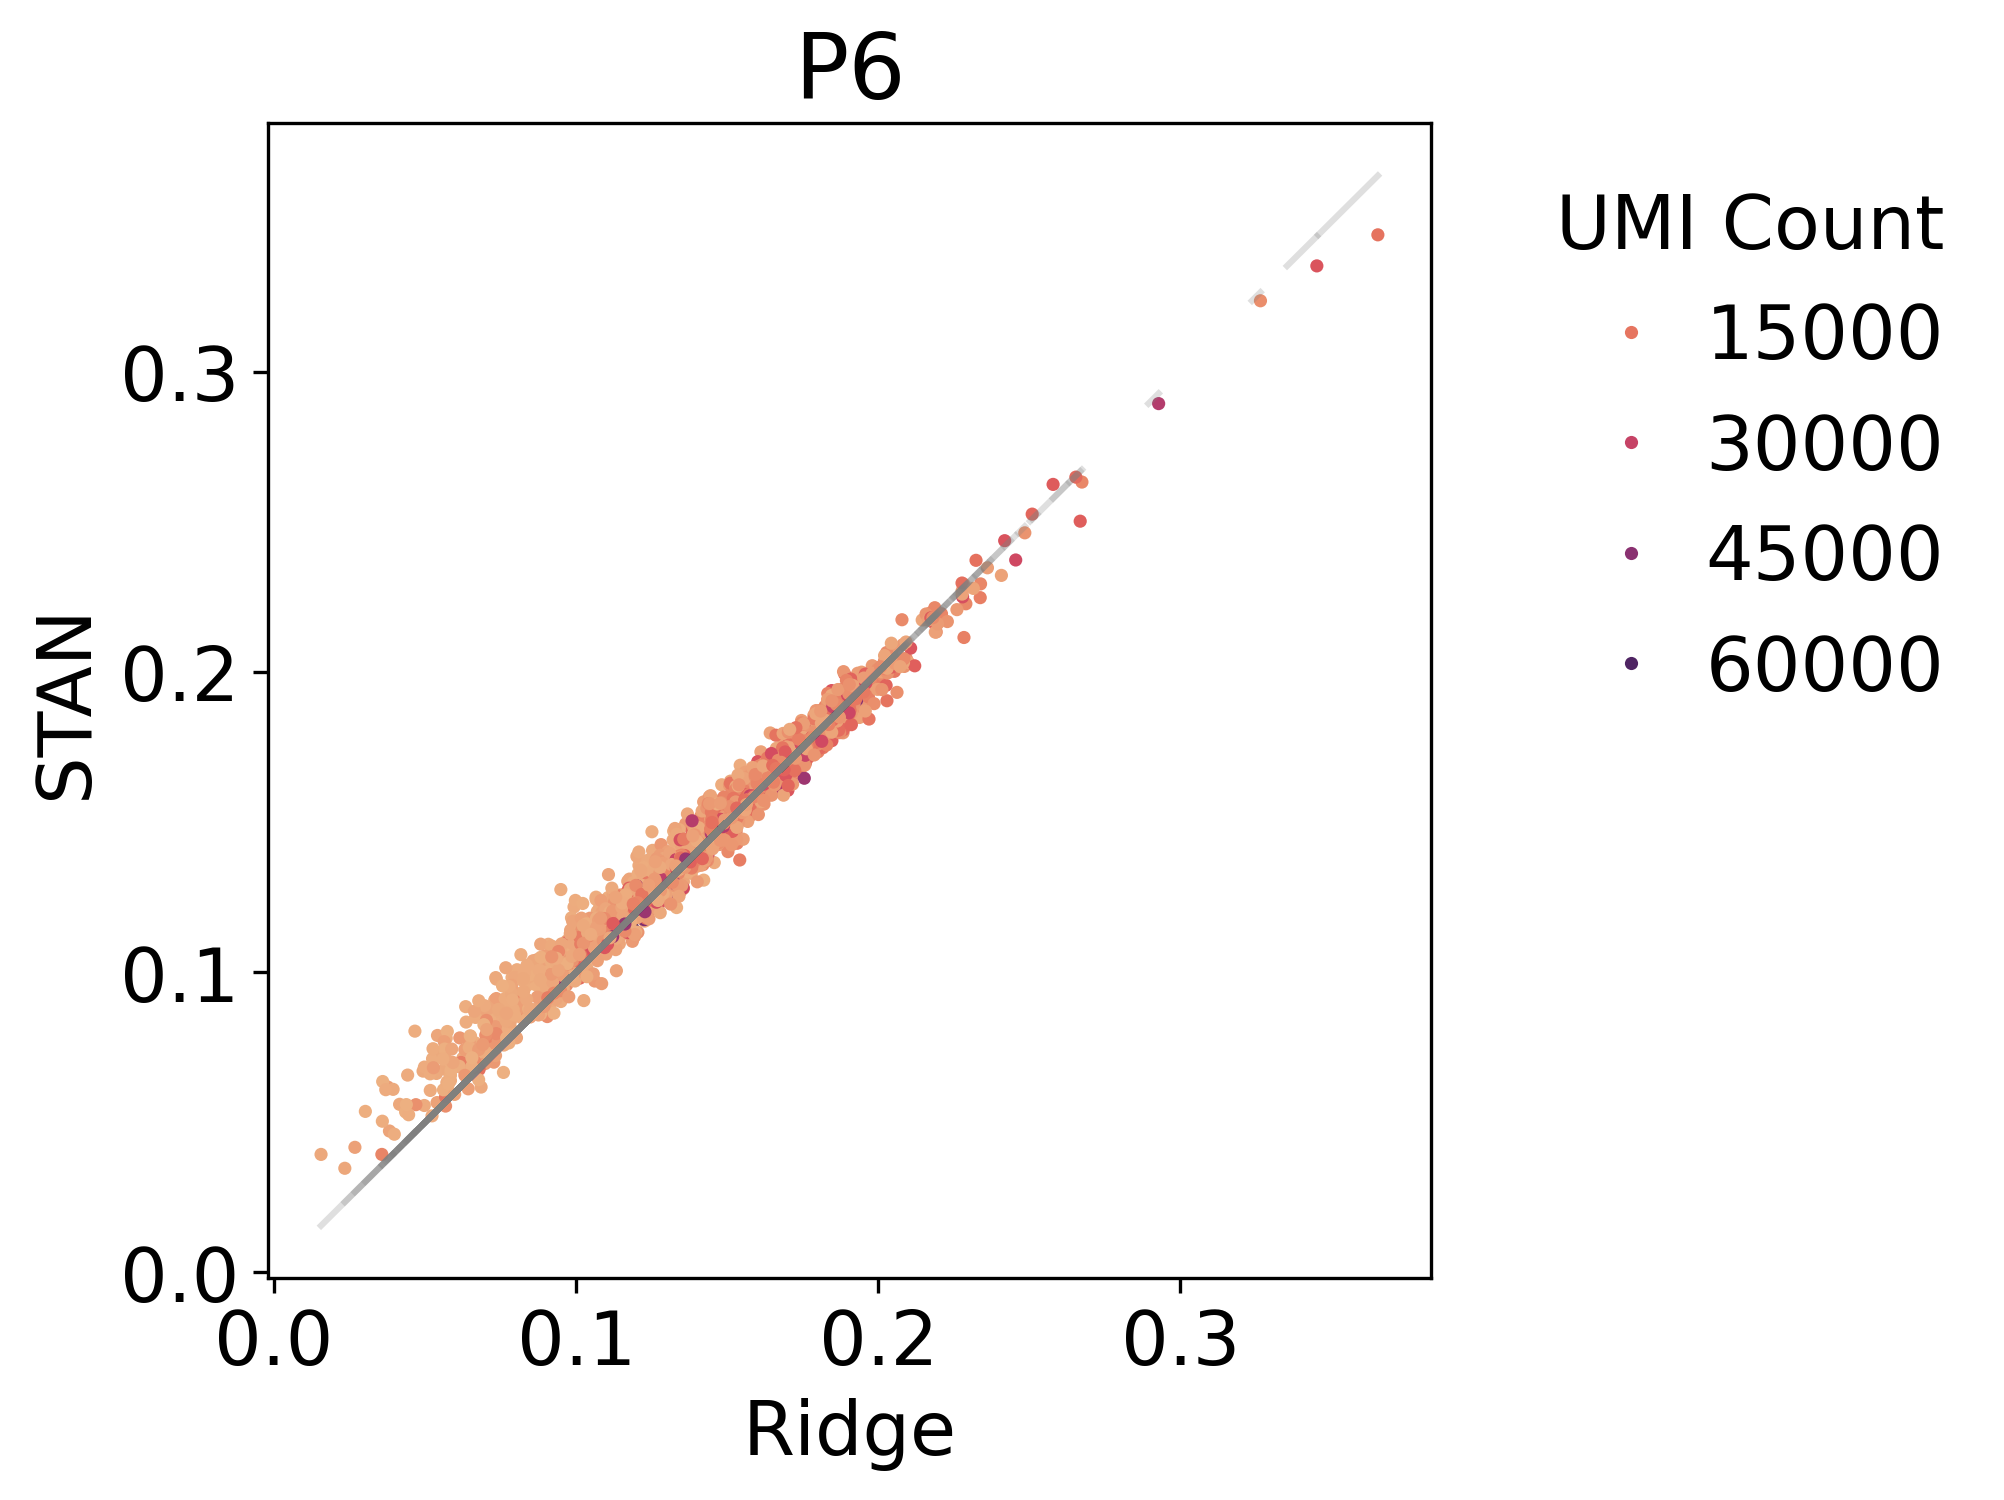

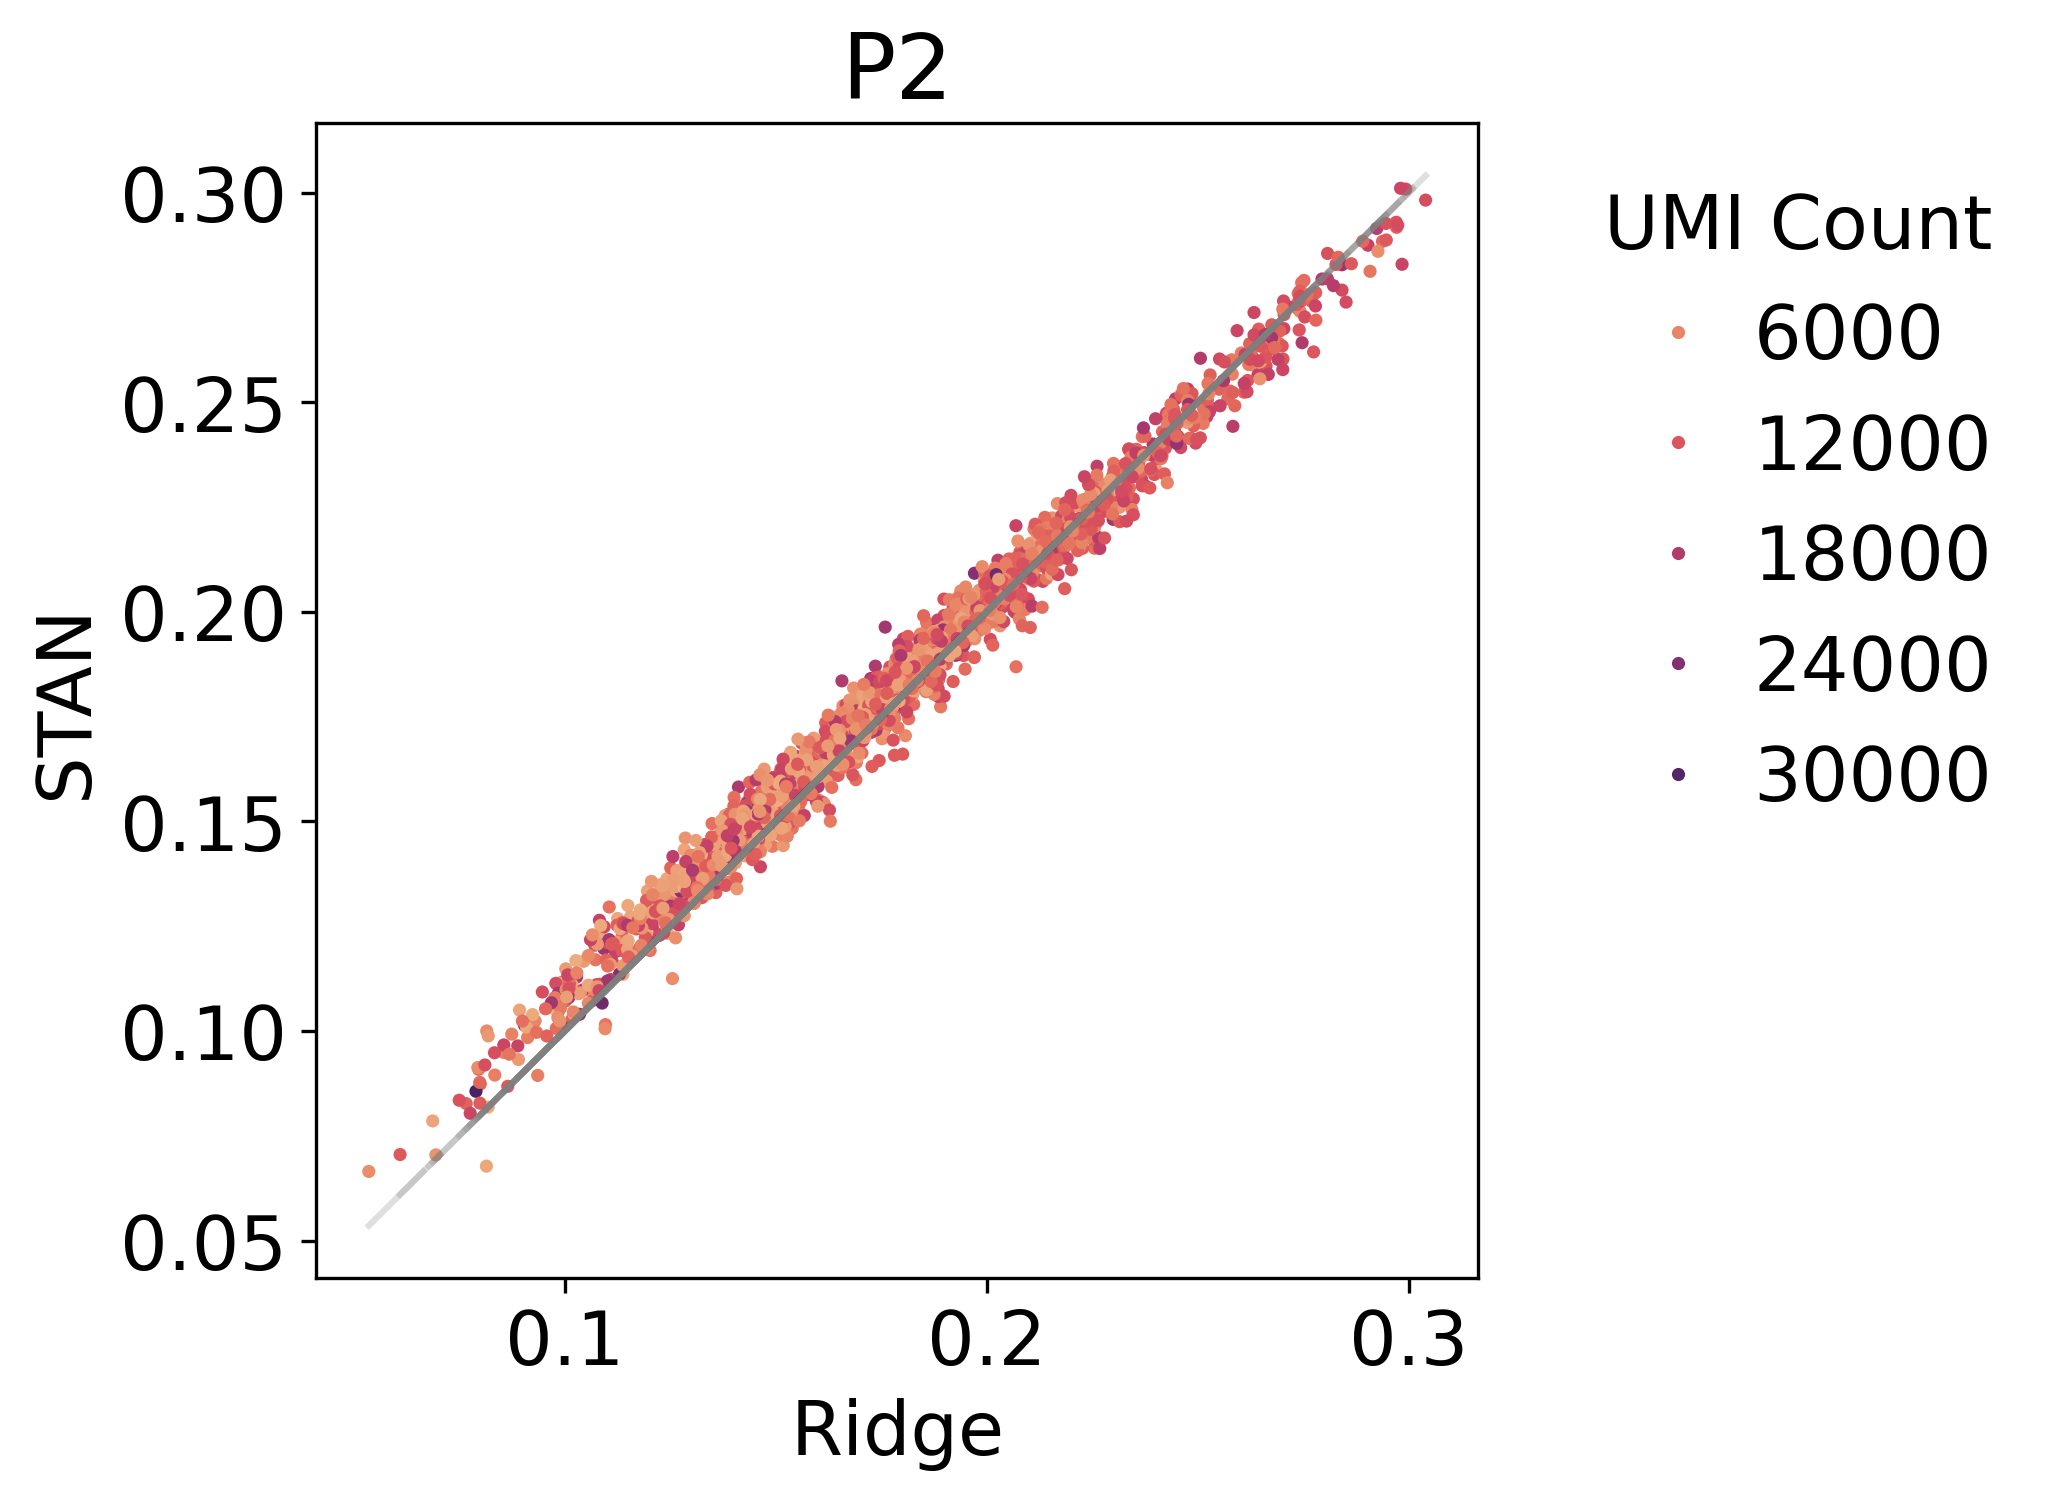

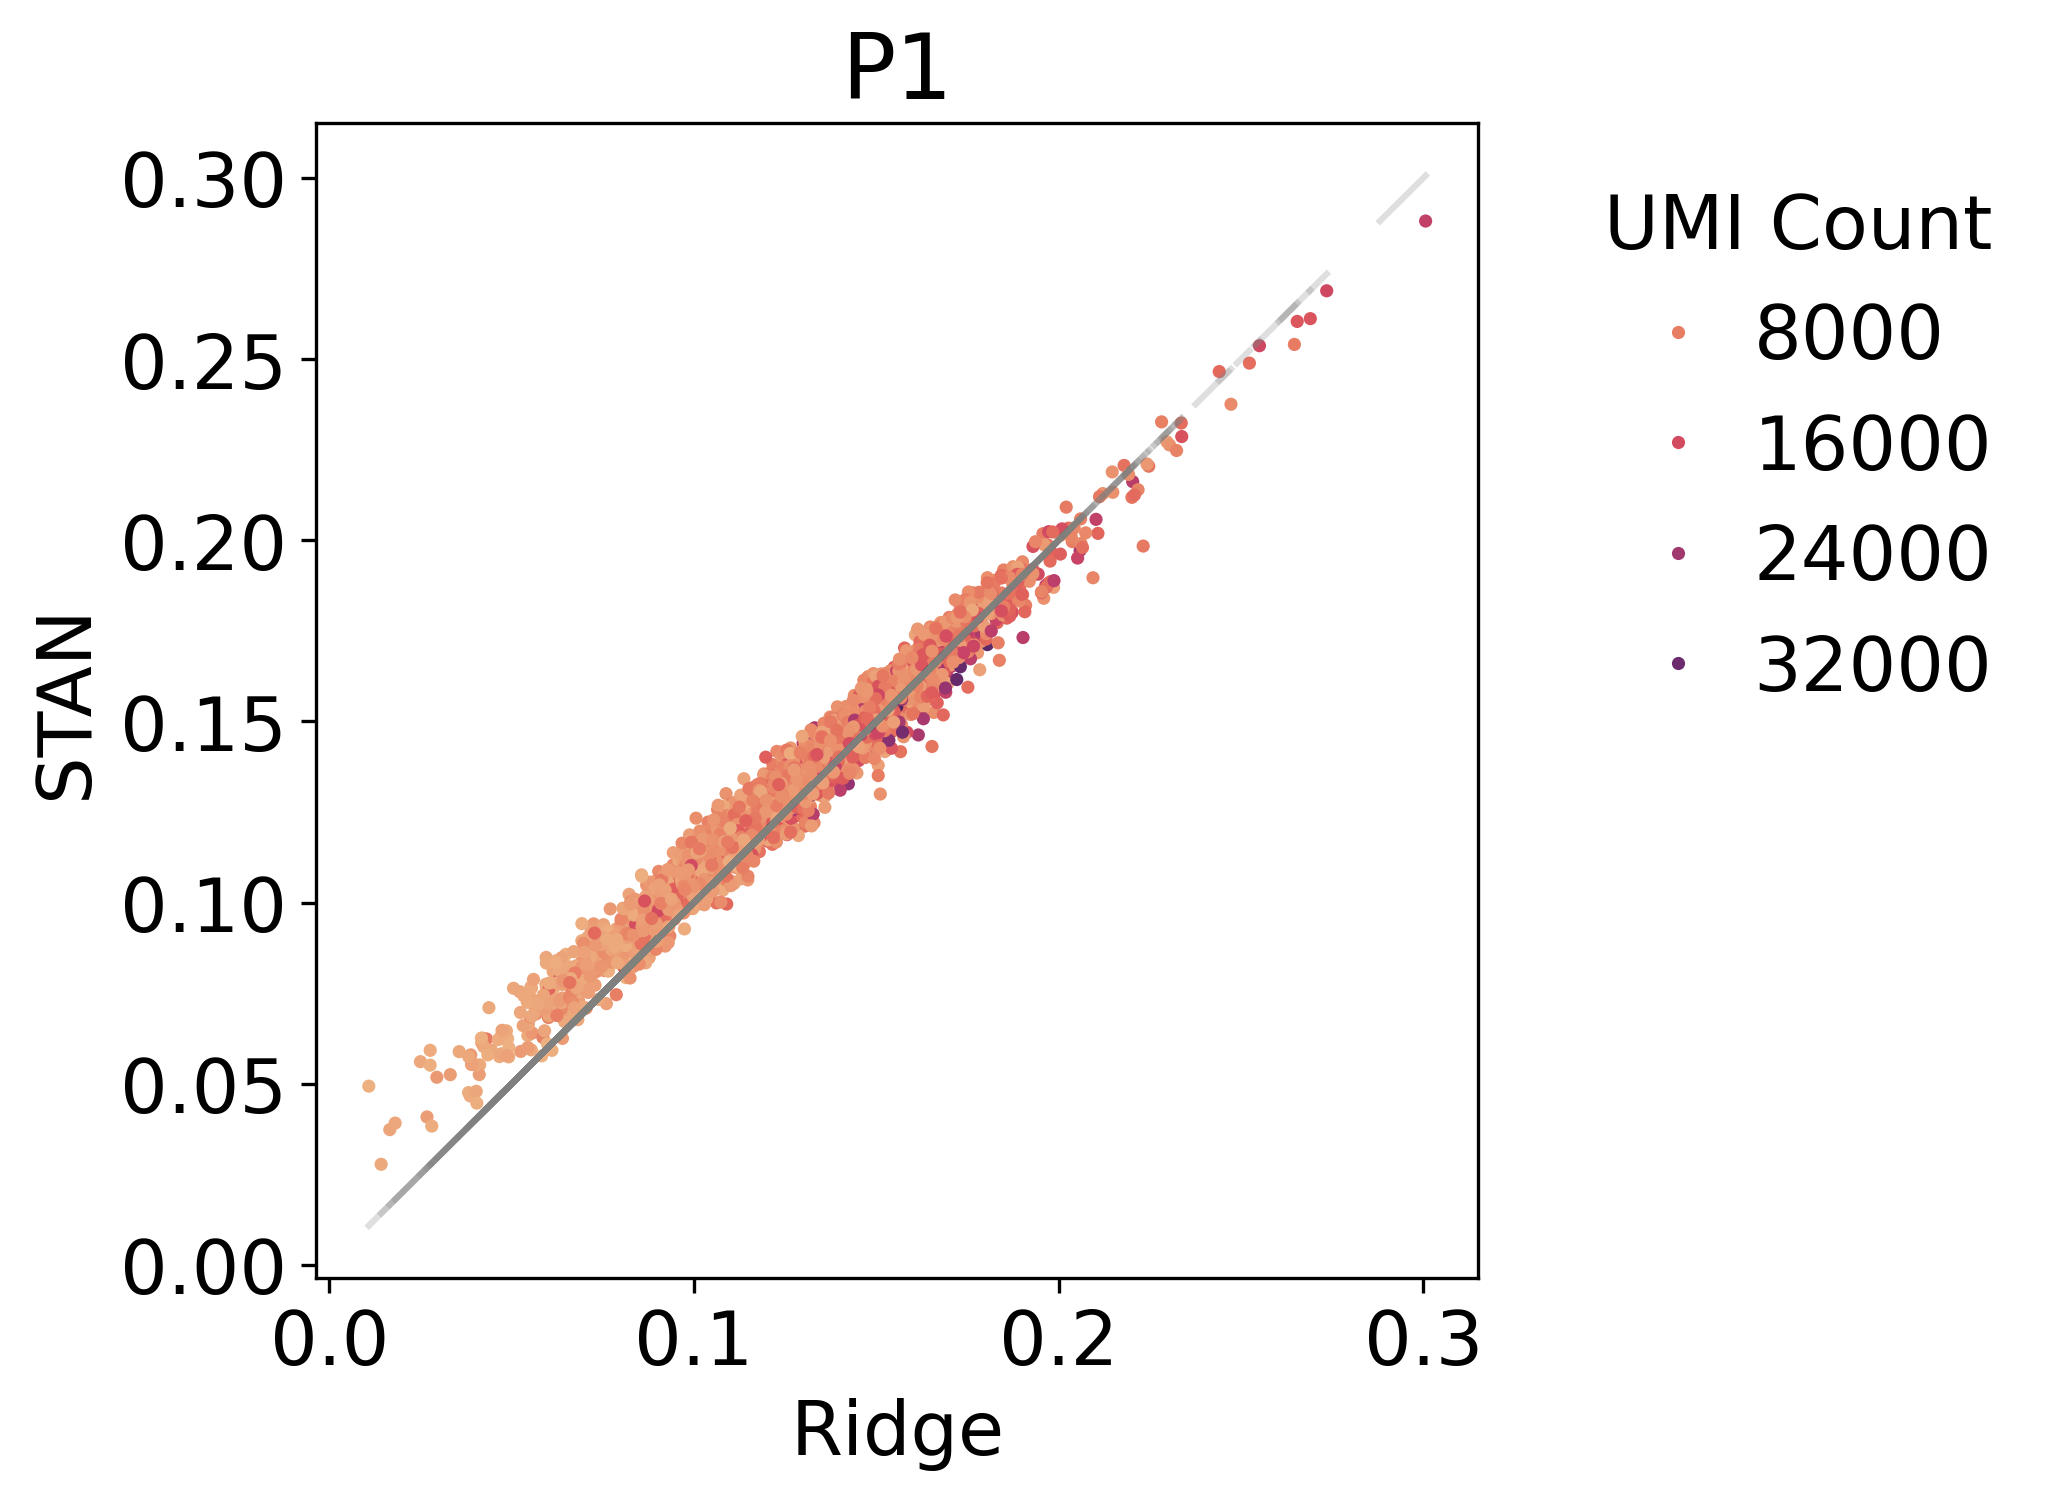

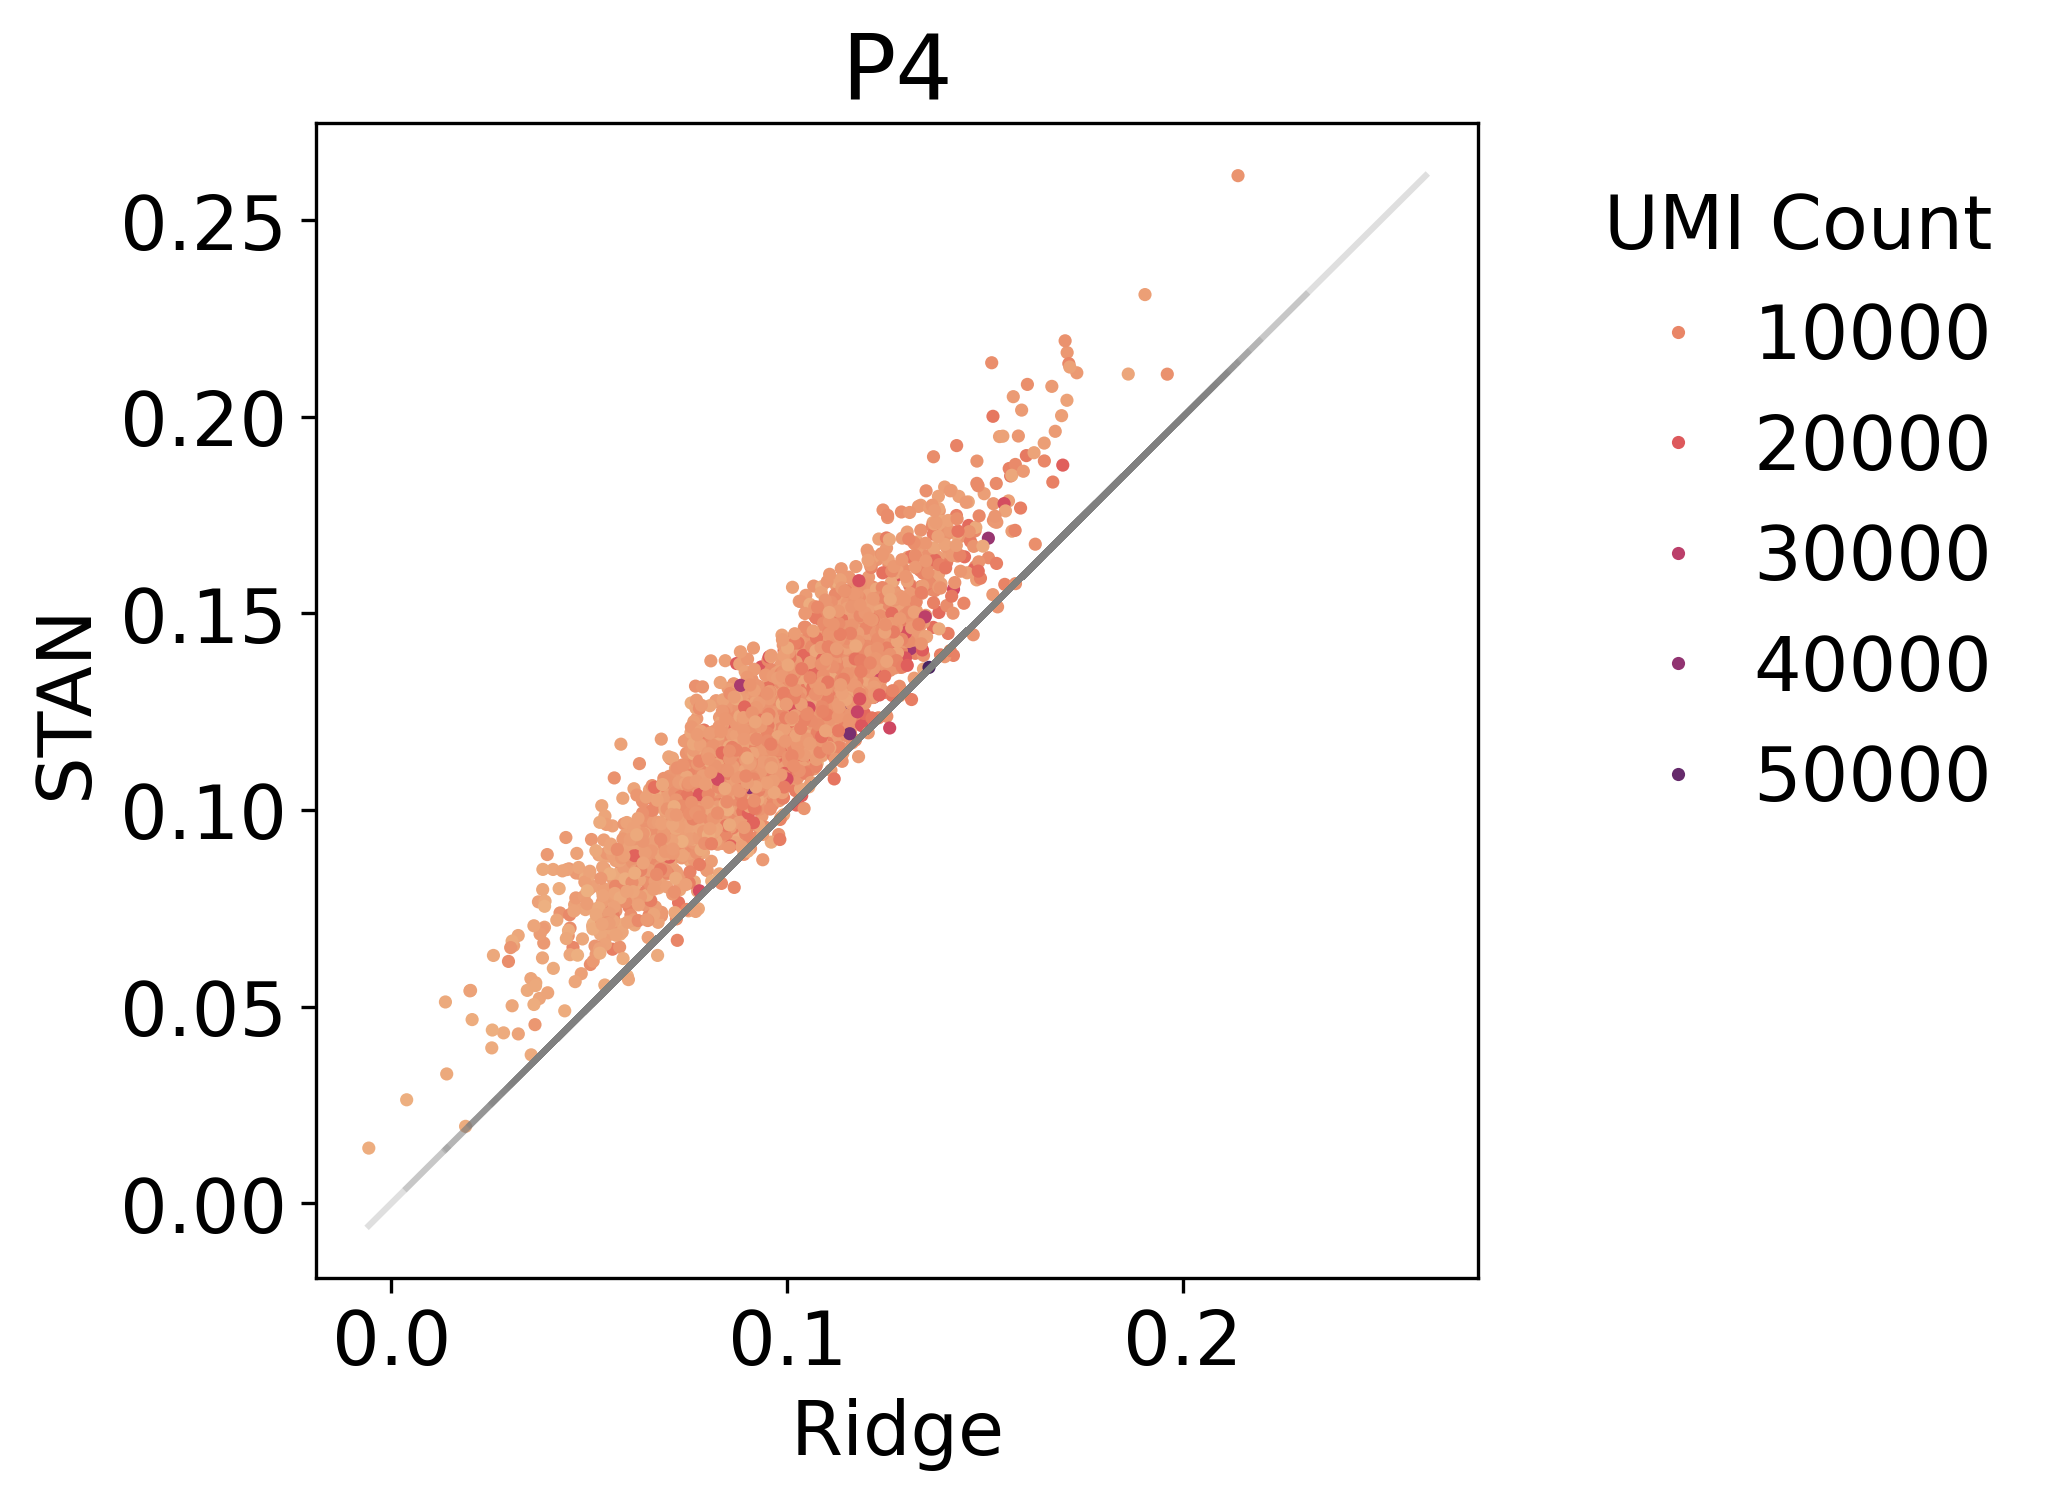

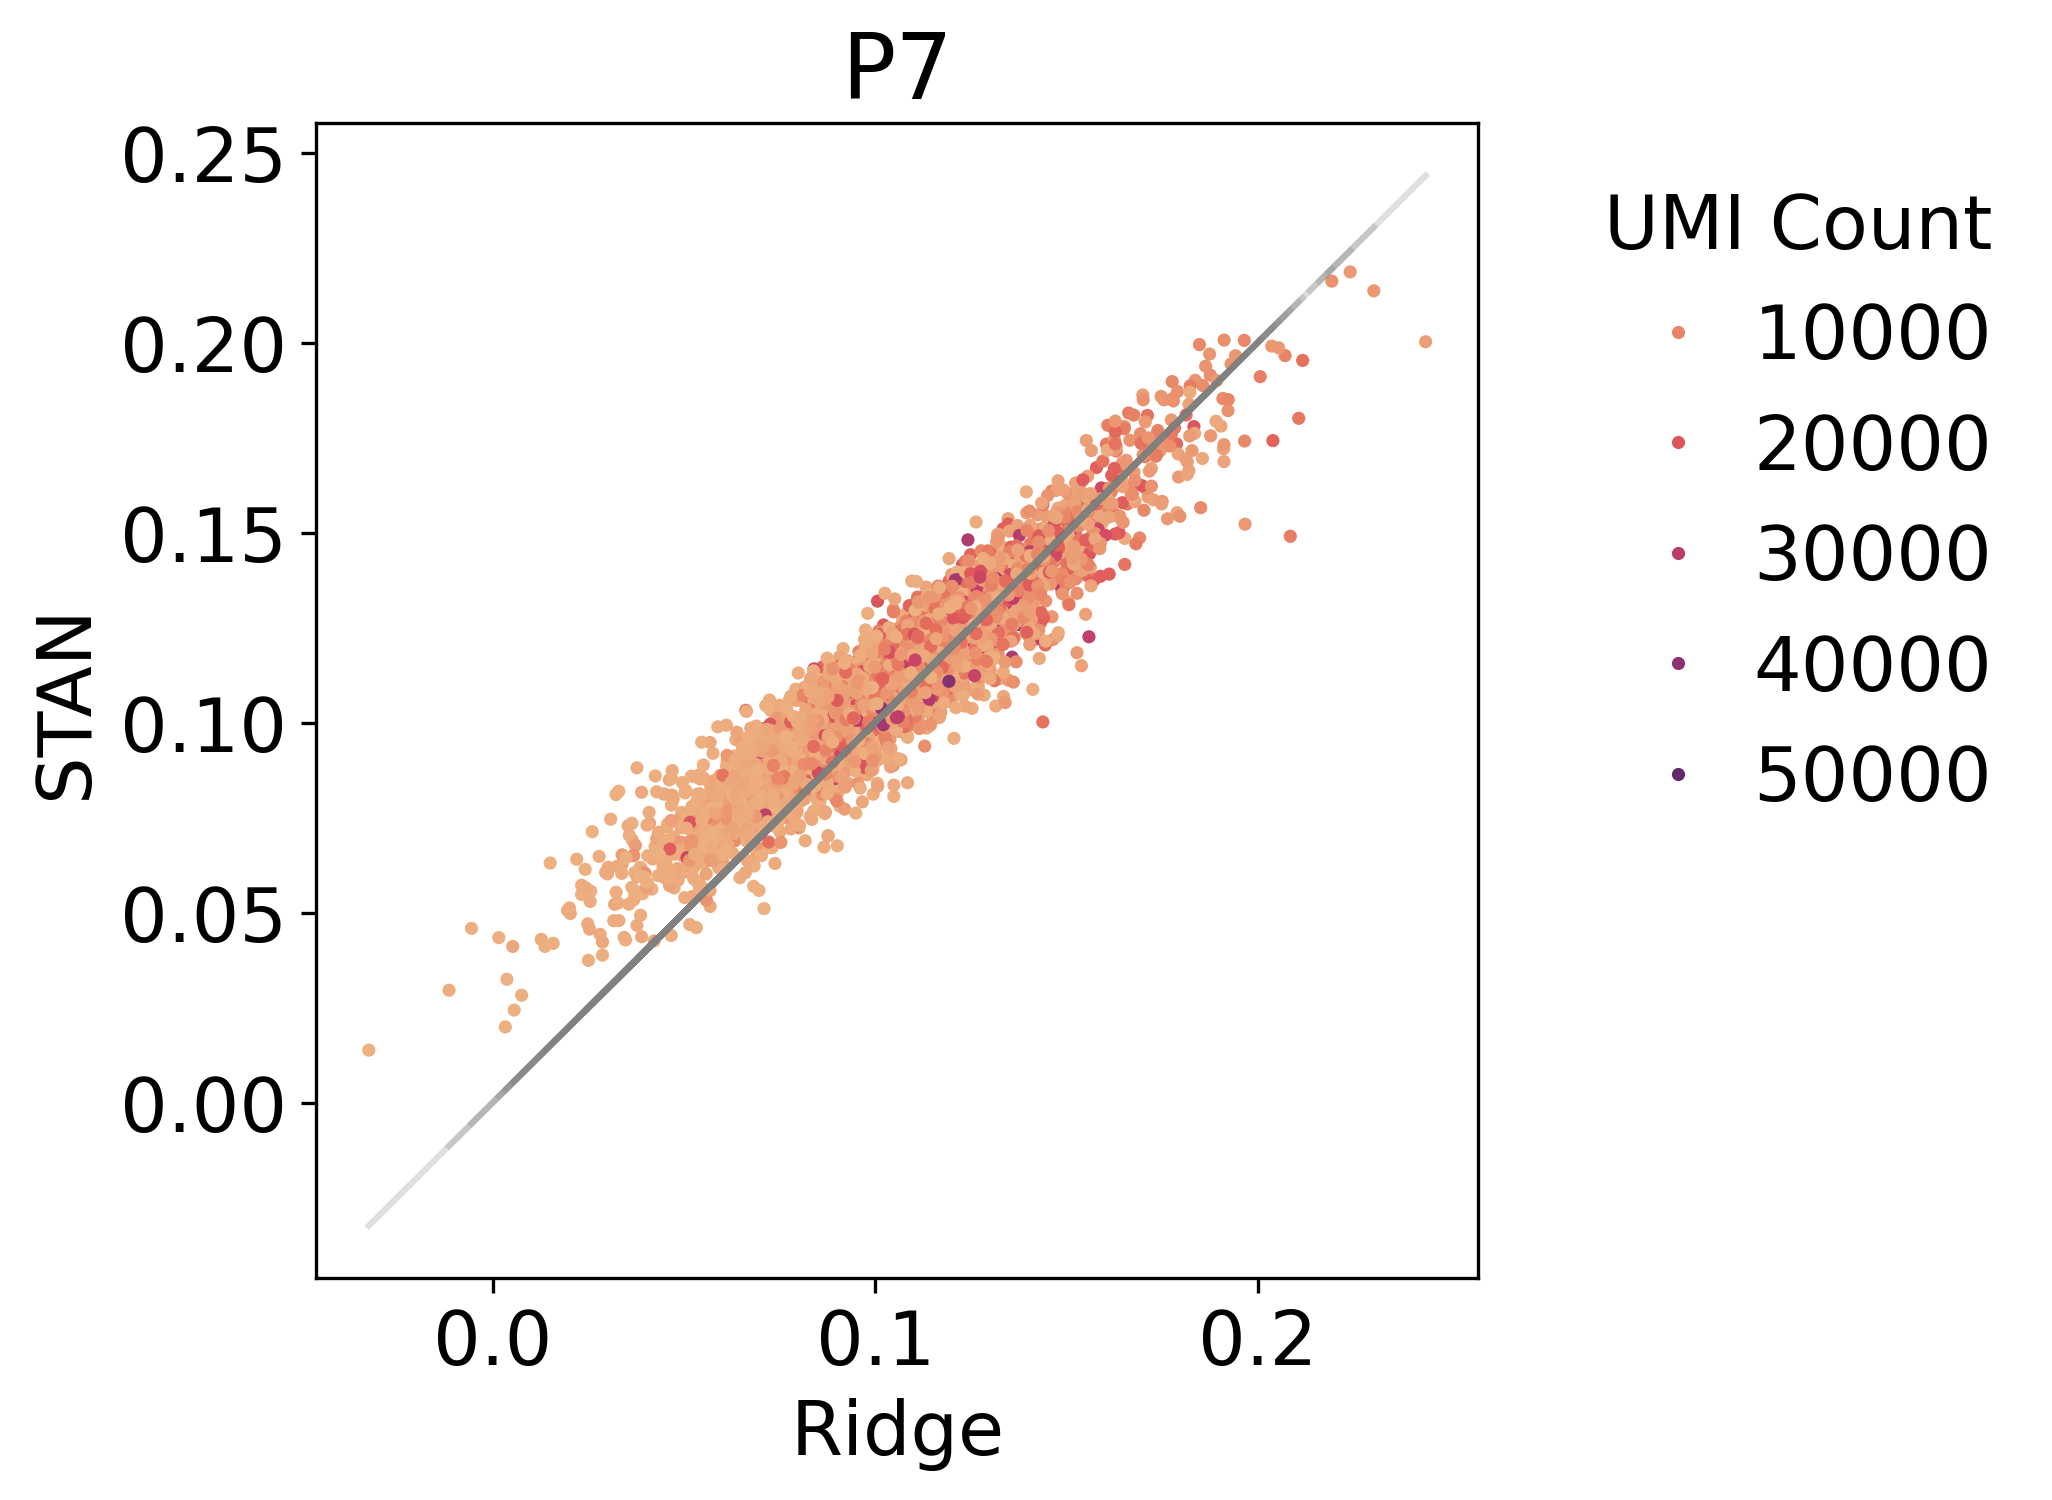

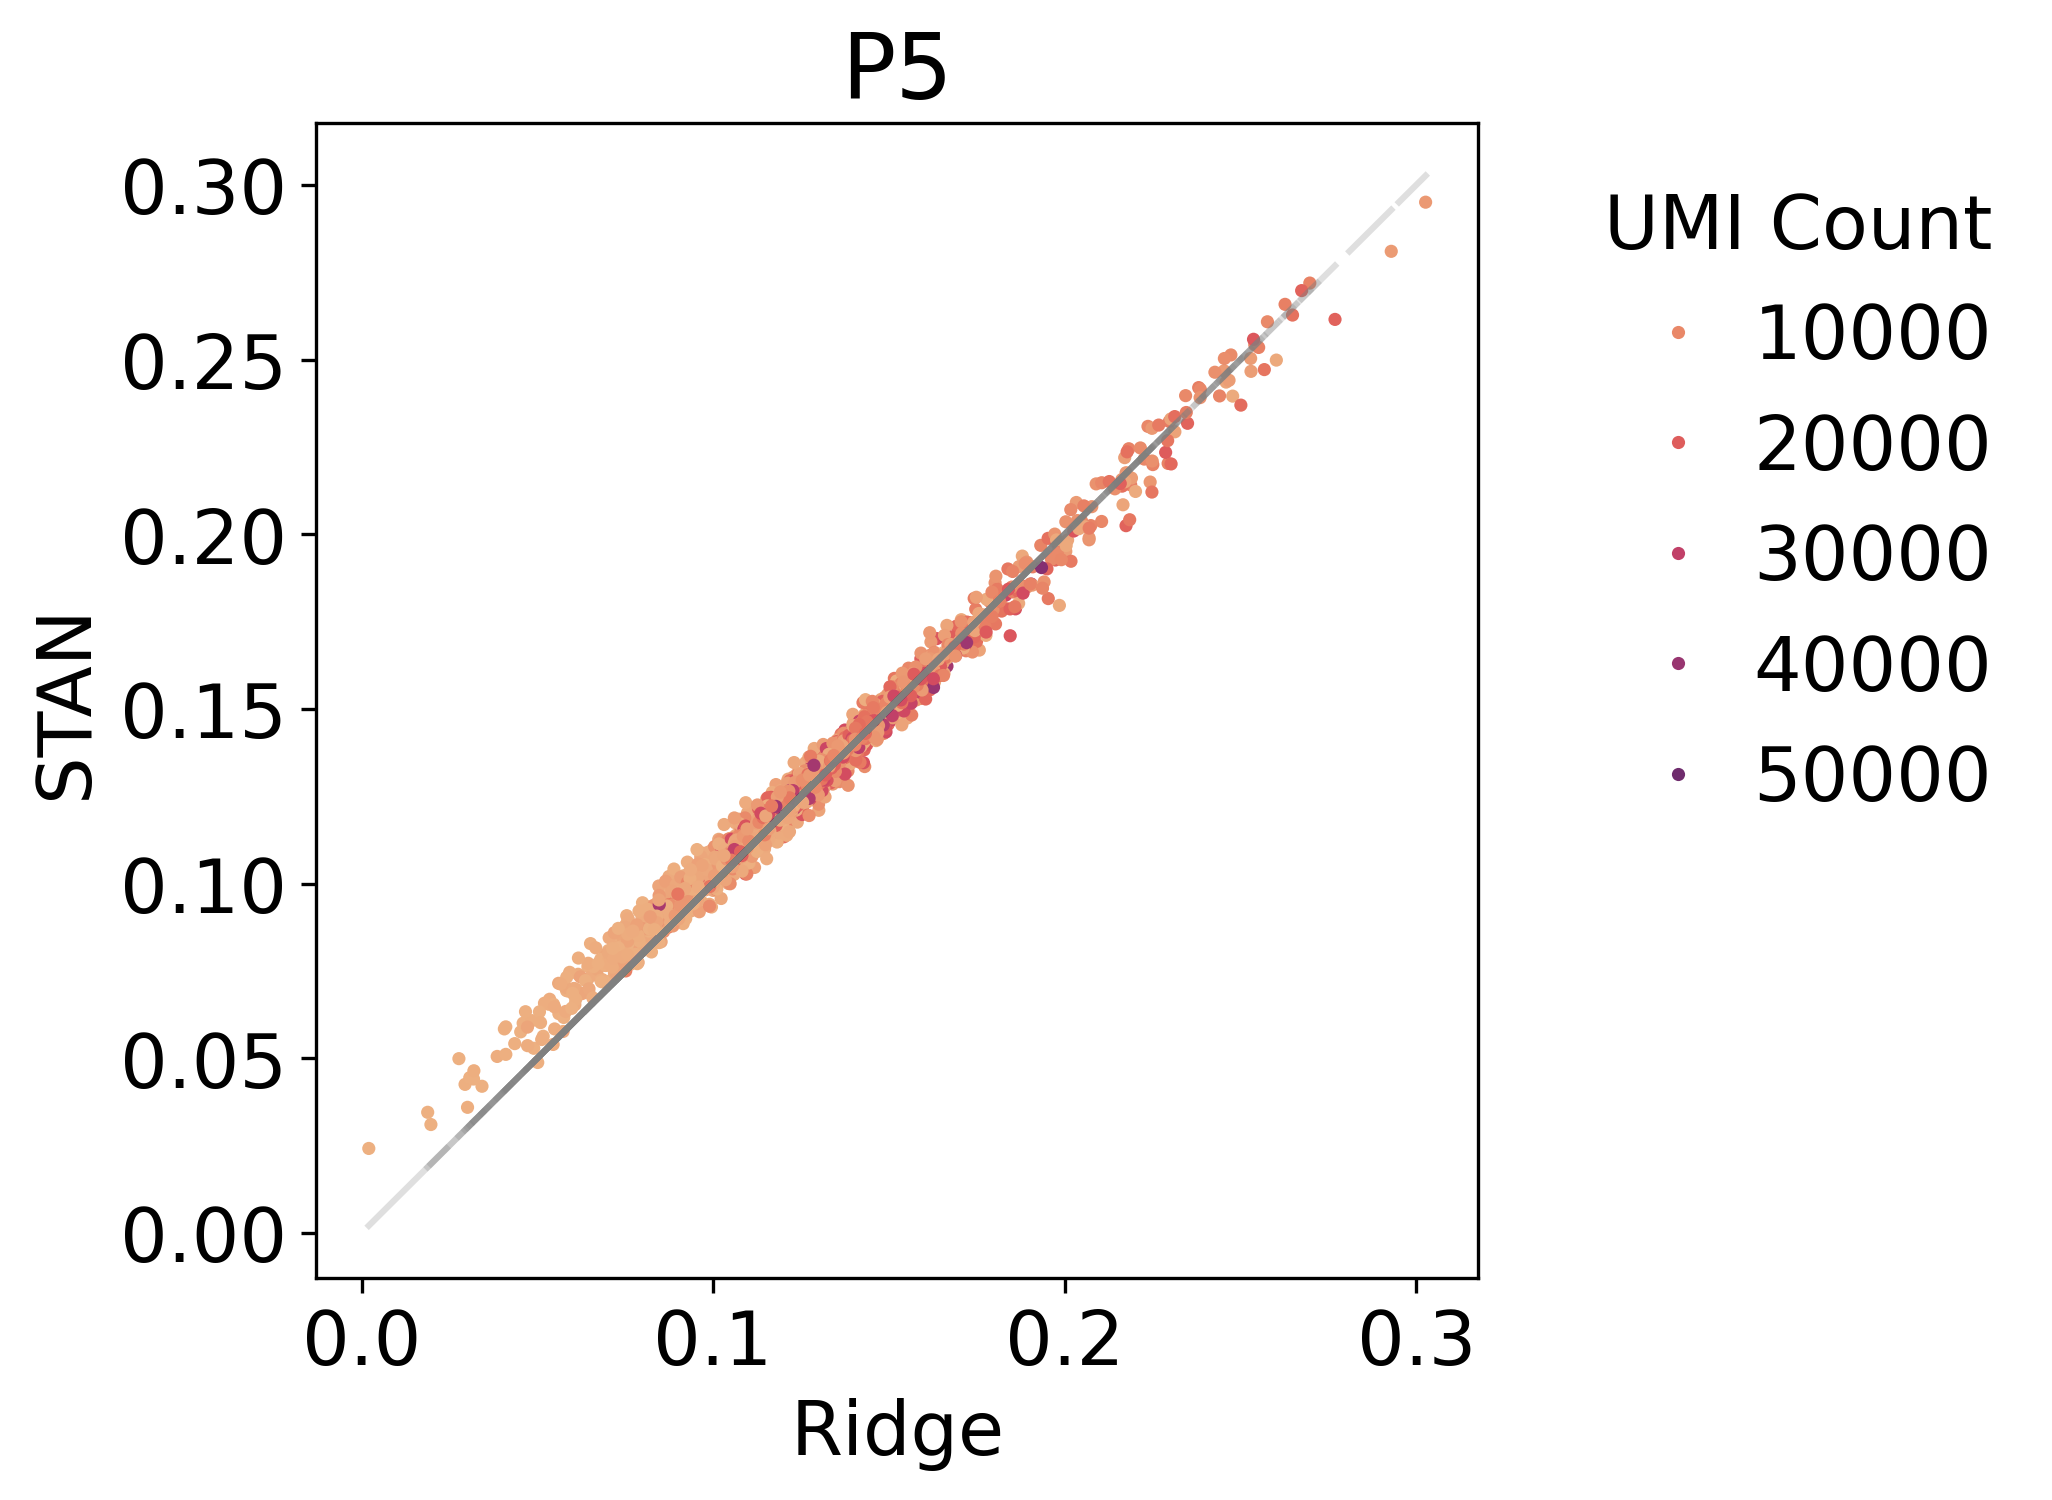

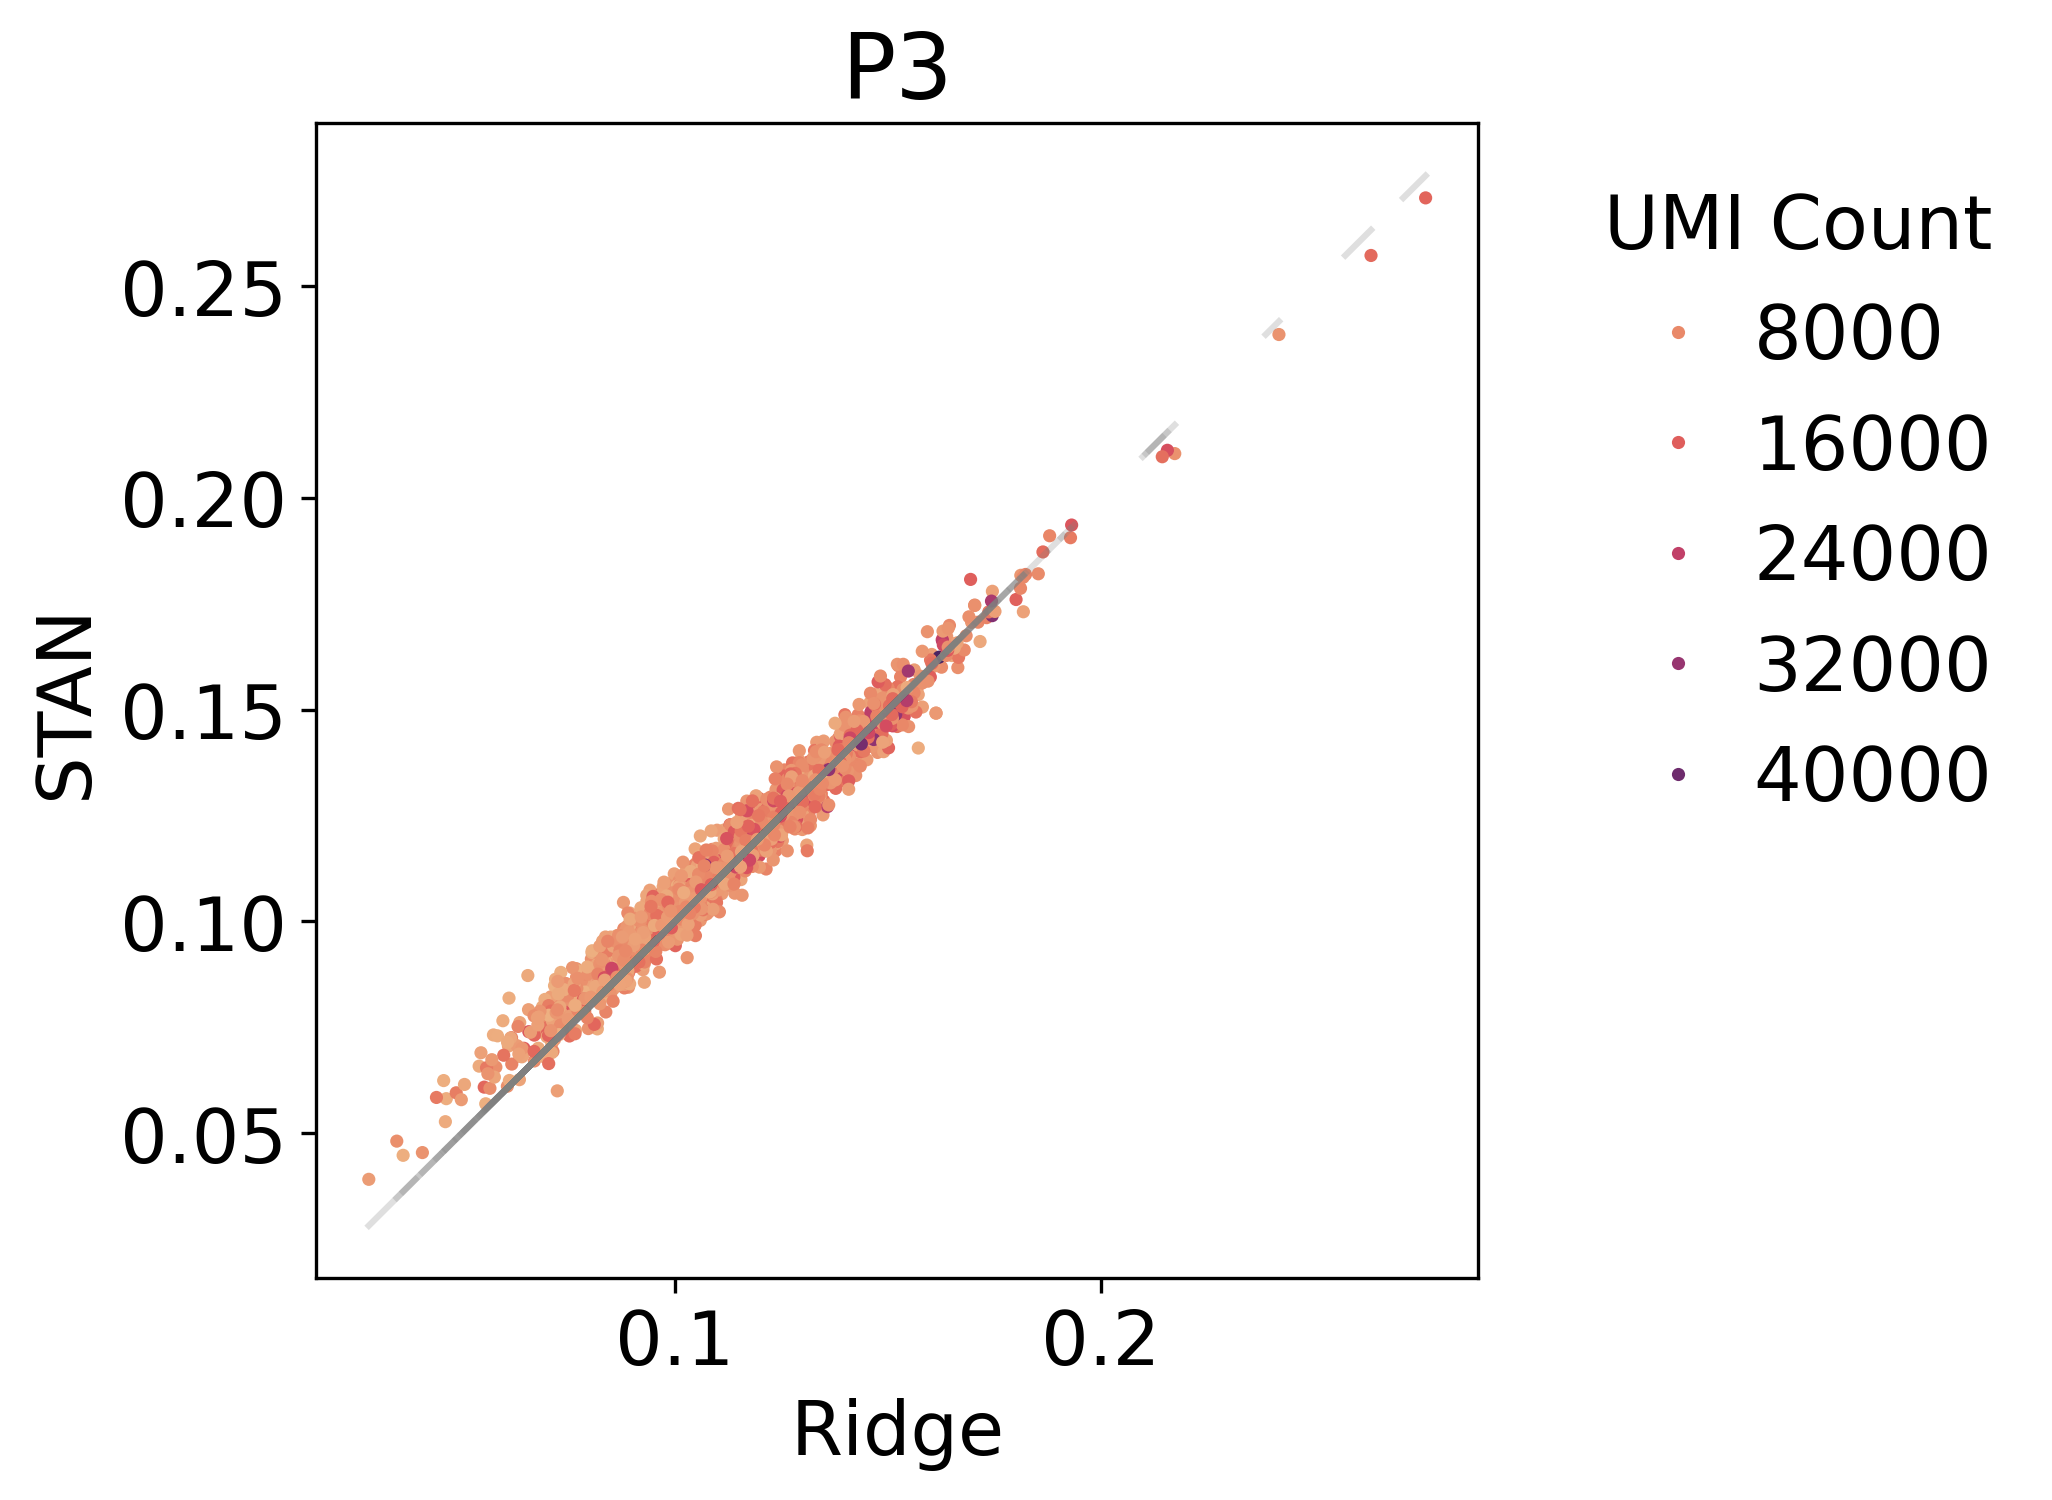

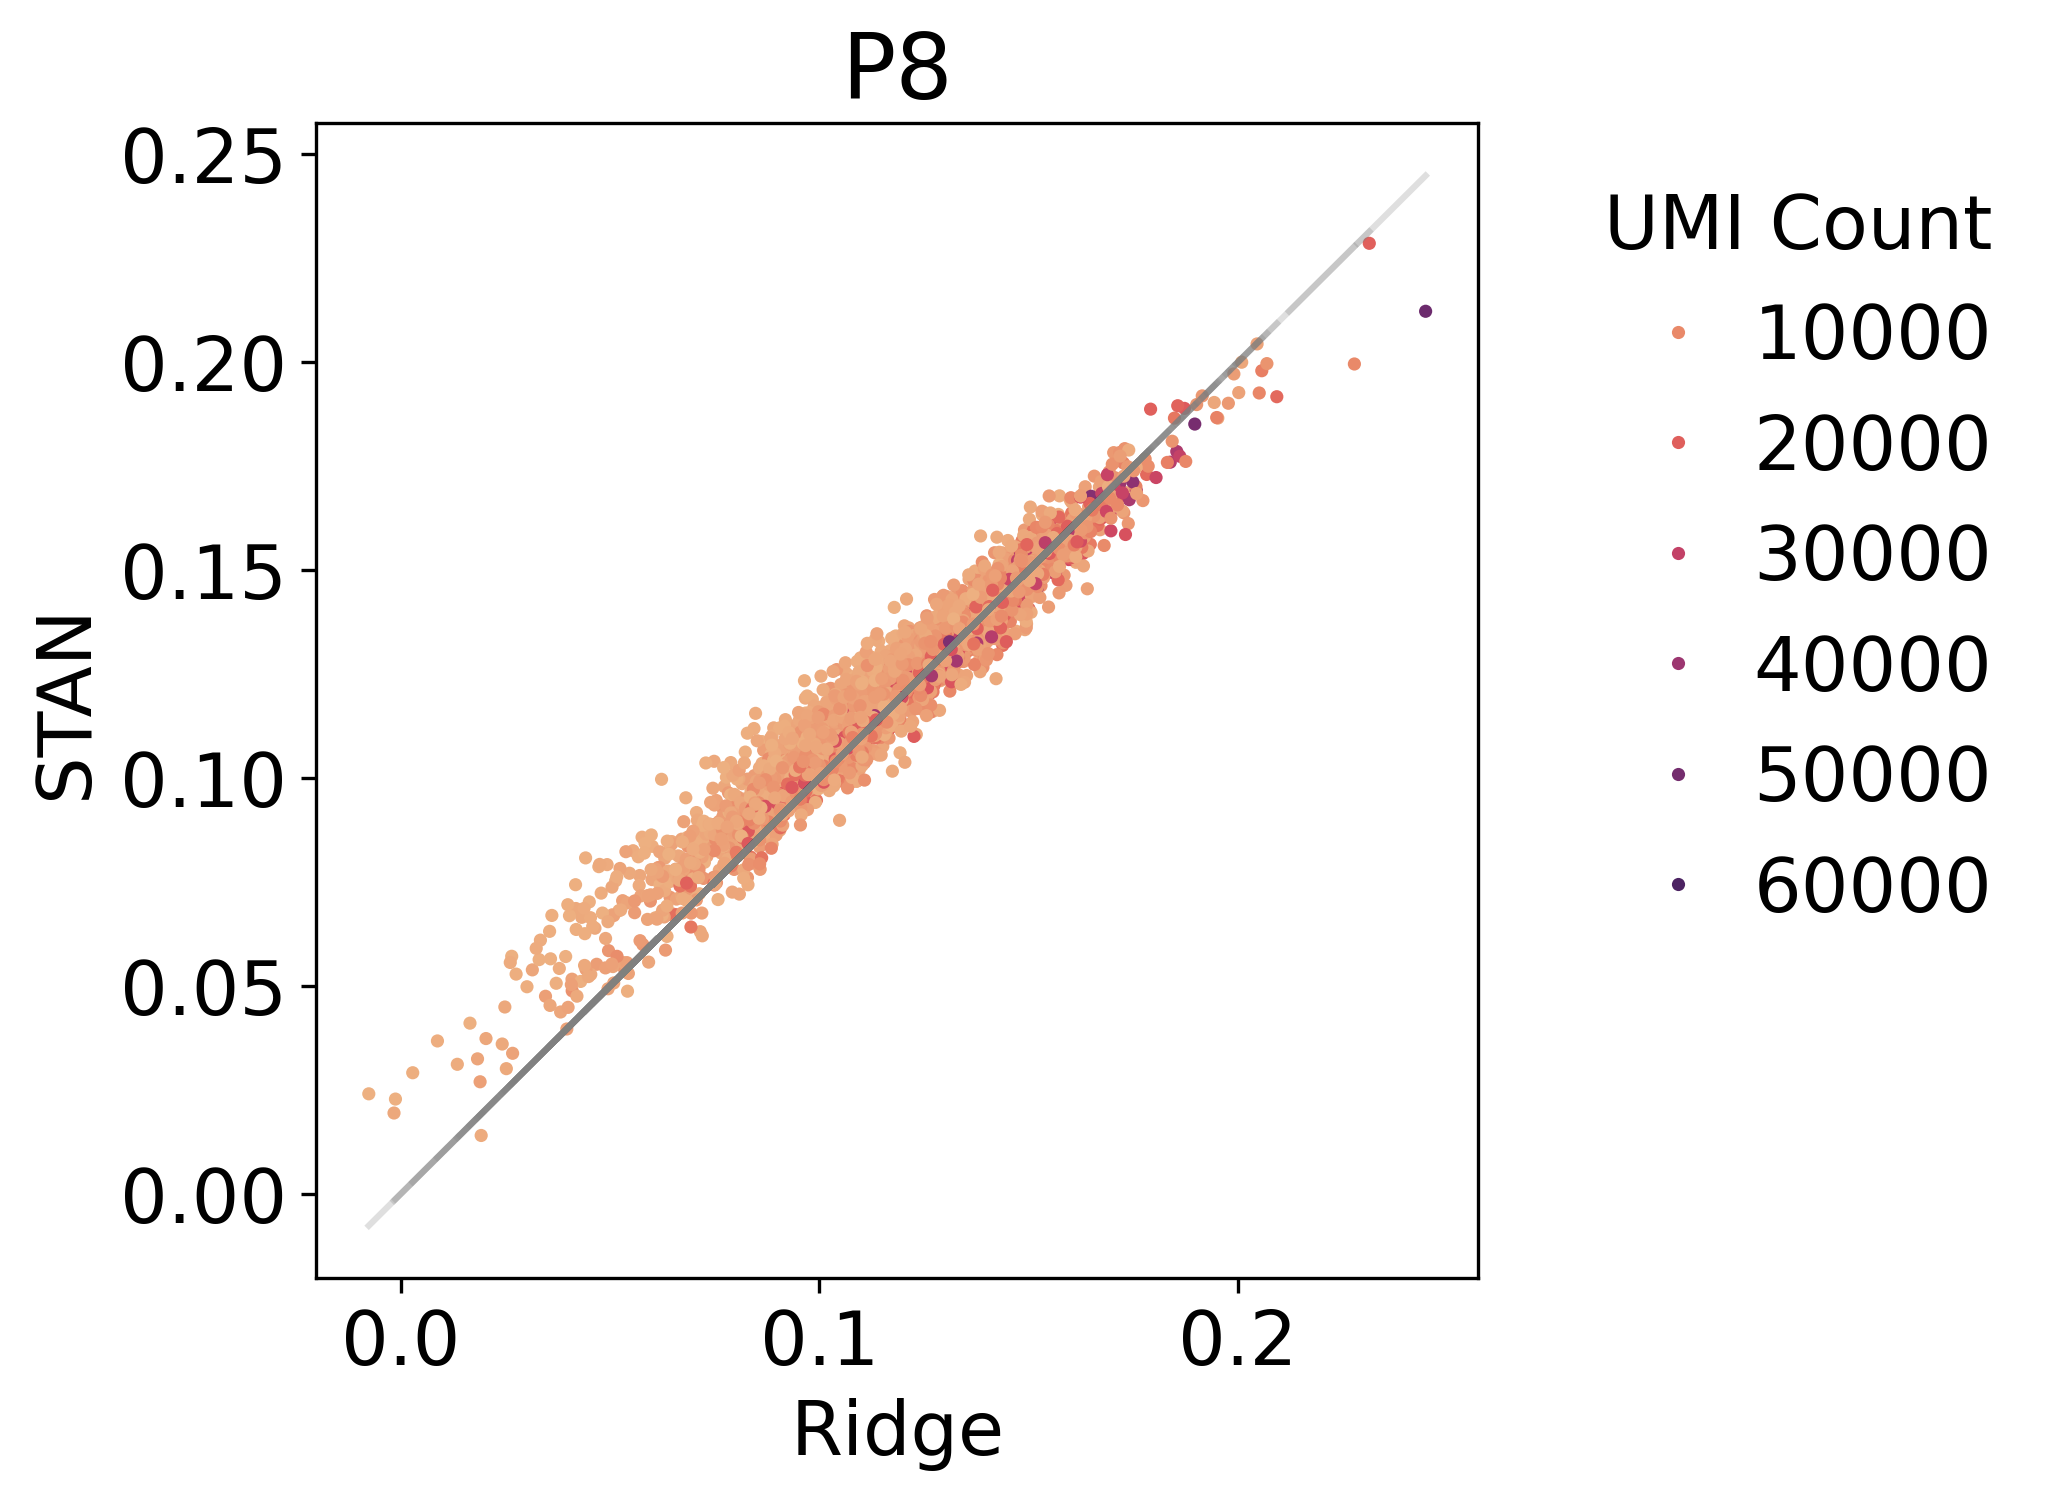

In [18]:
for sample in sample_list:
    auxpl.plot_validation(adatas[sample])
    plt.title(sample[12:14])

## Save the results

In [20]:
!mkdir ./results/st_span
for sample in sample_list:
    adatas[sample].write("./results/st_span/{}.h5ad".format(sample))